# MLP нейросеть — Fraud Detection

Строим простую нейросеть на PyTorch, обучаем с Focal Loss (для дисбаланса классов),  
логируем в MLflow и сравниваем с лучшим baseline — LightGBM (PR-AUC=0.836).

**Данные:** Credit Card Fraud Detection (Kaggle, ULB). Те же train/val/test сплиты что в ноутбуке 02. Архитектура: 30 → 128 (BN+ReLU+Dropout) → 64 → 32 → 1.

**Выводы:** MLP с Focal Loss не превзошёл LightGBM на этом датасете. Градиентный бустинг лучше подходит для табличных данных с анонимизированными признаками. Нейросеть обучается дольше и даёт сопоставимый или чуть худший PR-AUC.

In [9]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import mlflow
import mlflow.pytorch
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_recall_curve

from src.data.pipeline import load_data, split_data, fit_preprocessor, apply_preprocessor, get_X_y

DEVICE = torch.device('cpu')  # Mac M-chip: mps доступен, но cpu стабильнее для обучения
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)

mlflow.set_experiment('fraud_detection_baseline')
print(f'PyTorch: {torch.__version__} | device: {DEVICE}')

PyTorch: 2.4.0 | device: cpu


## 1. Загрузка данных

In [10]:
df = load_data('../data/creditcard.csv')
train, val, test = split_data(df)

# Загружаем препроцессор, обученный в ноутбуке 02
preprocessor = joblib.load('../models/preprocessor.pkl')

X_train = apply_preprocessor(preprocessor, train)
X_val   = apply_preprocessor(preprocessor, val)
X_test  = apply_preprocessor(preprocessor, test)

_, y_train = get_X_y(train)
_, y_val   = get_X_y(val)
_, y_test  = get_X_y(test)

# Переводим в тензоры
def to_tensors(X, y):
    return (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y.values, dtype=torch.float32),
    )

Xt_train, yt_train = to_tensors(X_train, y_train)
Xt_val,   yt_val   = to_tensors(X_val,   y_val)

train_loader = DataLoader(
    TensorDataset(Xt_train, yt_train),
    batch_size=512, shuffle=True
)
print(f'Train батчей: {len(train_loader)}, input_dim: {X_train.shape[1]}')

Train: 170,883  |  fraud: 295 (0.173%)
Val:   56,962  |  fraud: 99 (0.174%)
Test:  56,962  |  fraud: 98 (0.172%)
Train батчей: 334, input_dim: 30


## 2. Архитектура MLP и Focal Loss

In [11]:
class FraudMLP(nn.Module):
    """30 → 128 → 64 → 32 → 1. BatchNorm + Dropout для регуляризации."""

    def __init__(self, input_dim: int = 30, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


class FocalLoss(nn.Module):
    """Focal Loss — снижает вес лёгких примеров, фокусируется на сложных."""

    def __init__(self, alpha: float = 0.25, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()


model = FraudMLP(input_dim=X_train.shape[1]).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nПараметров всего: {total_params:,}')

FraudMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)

Параметров всего: 14,721


## 3. Обучение с Early Stopping

In [12]:
def evaluate_mlp(model, X_tensor, y_series, threshold=0.5):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor.to(DEVICE))
        scores = torch.sigmoid(logits).cpu().numpy()
    preds = (scores >= threshold).astype(int)
    y = y_series.values if hasattr(y_series, 'values') else y_series
    return {
        'pr_auc':  round(float(average_precision_score(y, scores)), 4),
        'roc_auc': round(float(roc_auc_score(y, scores)), 4),
        'f1':      round(float(f1_score(y, preds)), 4),
    }, scores


def train_mlp(model, train_loader, Xt_val, y_val,
              n_epochs=60, lr=1e-3, patience=8):

    criterion = FocalLoss(alpha=0.25, gamma=2.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=4
    )

    best_pr_auc = 0.0
    best_state  = None
    no_improve  = 0
    history     = {'train_loss': [], 'val_pr_auc': []}

    for epoch in range(1, n_epochs + 1):
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        metrics, _ = evaluate_mlp(model, Xt_val, y_val)
        val_pr_auc = metrics['pr_auc']

        history['train_loss'].append(avg_loss)
        history['val_pr_auc'].append(val_pr_auc)
        scheduler.step(val_pr_auc)

        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d} | loss={avg_loss:.4f} | val PR-AUC={val_pr_auc:.4f}')

        if val_pr_auc > best_pr_auc:
            best_pr_auc = val_pr_auc
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve  = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping на эпохе {epoch}, best PR-AUC={best_pr_auc:.4f}')
                break

    model.load_state_dict(best_state)
    return history, best_pr_auc

In [13]:
params_mlp = {
    'architecture': '30-128-64-32-1',
    'dropout': 0.3,
    'lr': 1e-3,
    'batch_size': 512,
    'loss': 'FocalLoss(alpha=0.25,gamma=2)',
    'optimizer': 'Adam+weight_decay=1e-4',
    'epochs_max': 60,
    'early_stopping_patience': 8,
}

with mlflow.start_run(run_name='MLP_FocalLoss'):
    mlflow.log_params(params_mlp)
    history, best_pr_auc = train_mlp(
        model, train_loader, Xt_val, y_val,
        n_epochs=60, lr=1e-3, patience=8
    )
    final_metrics, _ = evaluate_mlp(model, Xt_val, y_val)
    mlflow.log_metrics(final_metrics)
    mlflow.pytorch.log_model(model, 'model')

print('\nИтоговые метрики MLP на val:')
for k, v in final_metrics.items():
    print(f'  {k}: {v}')

Epoch  10 | loss=0.0003 | val PR-AUC=0.7068
Early stopping на эпохе 10, best PR-AUC=0.7205


2026/05/28 00:56:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Итоговые метрики MLP на val:
  pr_auc: 0.7205
  roc_auc: 0.9787
  f1: 0.7807


## 4. Кривые обучения

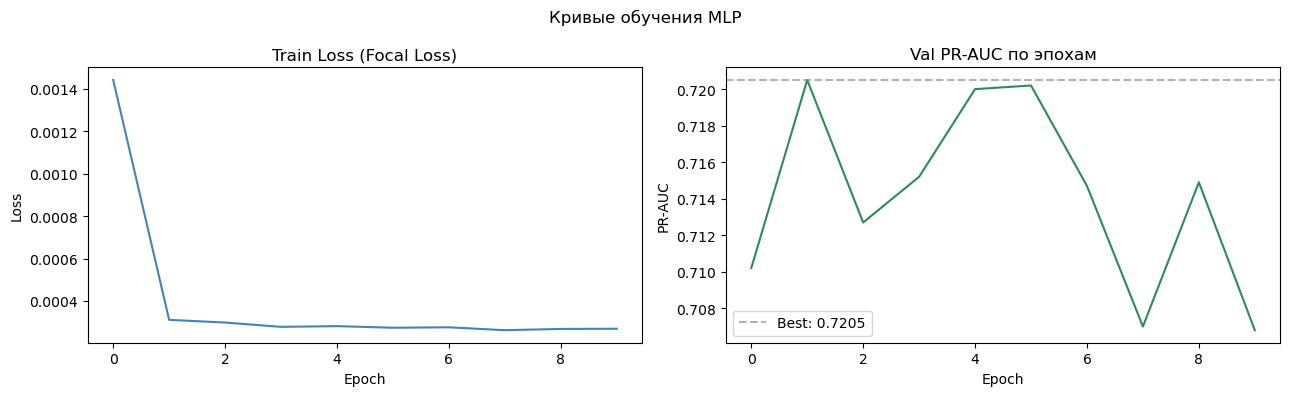

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['train_loss'], color='steelblue')
axes[0].set_title('Train Loss (Focal Loss)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(history['val_pr_auc'], color='seagreen')
axes[1].axhline(y=max(history['val_pr_auc']), color='gray', linestyle='--', alpha=0.6,
                label=f'Best: {max(history["val_pr_auc"]):.4f}')
axes[1].set_title('Val PR-AUC по эпохам')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('PR-AUC')
axes[1].legend()

plt.suptitle('Кривые обучения MLP')
plt.tight_layout()
plt.savefig('../artifacts/mlp_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Сравнение MLP с baseline-моделями

=== Все модели (val-выборка) ===
              pr_auc  roc_auc      f1
LightGBM      0.8359   0.9732  0.8432
XGBoost       0.8257   0.9722  0.8324
RandomForest  0.7798   0.9691  0.8022
MLP           0.7205   0.9787  0.7807
LogReg        0.6734   0.9748  0.1112


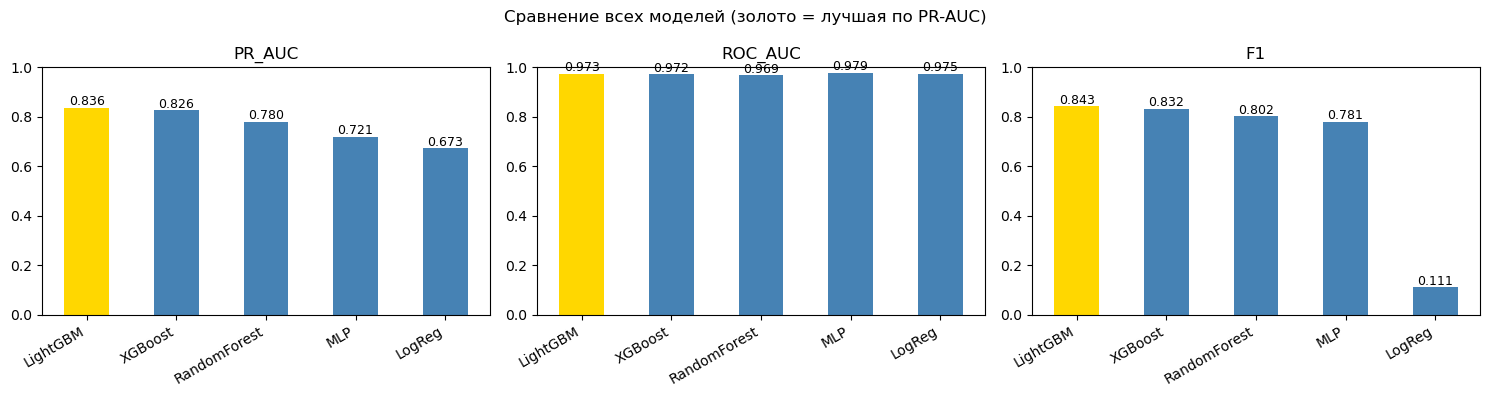

In [15]:
# Результаты из ноутбука 02
baseline_results = {
    'LogReg':      {'pr_auc': 0.6734, 'roc_auc': 0.9748, 'f1': 0.1112},
    'RandomForest':{'pr_auc': 0.7798, 'roc_auc': 0.9691, 'f1': 0.8022},
    'XGBoost':     {'pr_auc': 0.8257, 'roc_auc': 0.9722, 'f1': 0.8324},
    'LightGBM':    {'pr_auc': 0.8359, 'roc_auc': 0.9732, 'f1': 0.8432},
    'MLP':         final_metrics,
}

all_results = pd.DataFrame(baseline_results).T
all_results = all_results.sort_values('pr_auc', ascending=False)

print('=== Все модели (val-выборка) ===')
print(all_results.to_string())

# График сравнения
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(all_results))]

for ax, metric in zip(axes, ['pr_auc', 'roc_auc', 'f1']):
    all_results[metric].plot(kind='bar', ax=ax, color=colors)
    ax.set_title(metric.upper())
    ax.set_xticklabels(all_results.index, rotation=30, ha='right')
    ax.set_ylim(0, 1)
    for i, v in enumerate(all_results[metric]):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Сравнение всех моделей (золото = лучшая по PR-AUC)')
plt.tight_layout()
plt.savefig('../artifacts/all_models_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Итоги сессии 3

In [16]:
best_model_name = all_results.index[0]
best_pr_auc_val = all_results.loc[best_model_name, 'pr_auc']

print('=' * 50)
print('ИТОГИ СЕССИИ 3')
print('=' * 50)
print(all_results.to_string())
print()
print(f'Лучшая модель: {best_model_name} (PR-AUC={best_pr_auc_val})')
print()
print('Следующий шаг: ноутбук 04 — финальный выбор, упаковка модели')

ИТОГИ СЕССИИ 3
              pr_auc  roc_auc      f1
LightGBM      0.8359   0.9732  0.8432
XGBoost       0.8257   0.9722  0.8324
RandomForest  0.7798   0.9691  0.8022
MLP           0.7205   0.9787  0.7807
LogReg        0.6734   0.9748  0.1112

Лучшая модель: LightGBM (PR-AUC=0.8359)

Следующий шаг: ноутбук 04 — финальный выбор, упаковка модели
